In [1]:
import mlflow
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import os
import time
import functools
from IPython import display as ipythondisplay
from tqdm import tqdm
from scipy.io.wavfile import write
import pathlib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlflow.pytorch.autolog()

# RNN Network

## Arquitecture

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    """
    LSTM model for MIDI tensors with shape (batch, duration, 12, 128).
      - duration  : variable length (sequence timesteps)
      - 12        : number of instrument tracks (constant)
      - 128       : MIDI pitches (constant)

    Strategy: flatten (12, 128) → 1536 features per timestep,
    feed into LSTM, project output back to 12 × 128.
    """

    def __init__(self, input_dim=1*128, hidden_size=512, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers   = num_layers

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # step 2: LSTM over the projected sequence
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # step 3: project LSTM output back to (12, 128) logits
        self.output_proj = nn.Linear(hidden_size, input_dim)

    # ── Hidden state initializer ─────────────────────────────────────────────
    def init_hidden(self, batch_size, device):
        """Returns (h_0, c_0) zeroed tensors for the LSTM."""
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h0, c0)

    # ── Forward pass ─────────────────────────────────────────────────────────
    def forward(self, x, state=None, return_state=False):
        """
        Args:
            x           : (B, 30, 12, 128)  float tensor
            state       : optional (h, c) tuple from a previous call
            return_state: if True, also returns (h, c) for autoregressive use

        Returns:
            out         : (B, 30, 12, 128)  logits
            (optional)  : (h_n, c_n)  hidden state
        """
        B, T, rows, cols = x.shape

        # flatten piano roll frame into a single vector per timestep
        x_flat = x.view(B, T, rows * cols)              # (B, T, 1536)

        # project to LSTM input size
        x_proj = self.input_proj(x_flat)                # (B, T, 512)

        if state is None:
            state = self.init_hidden(B, x.device)

        lstm_out, state = self.lstm(x_proj, state)      # (B, T, hidden)

        # project back to piano roll logit space
        logits = self.output_proj(lstm_out)             # (B, T, 1536)

        # reshape to match input format
        out = logits.view(B, T, rows, cols)             # (B, T, 12, 128)

        return out if not return_state else (out, state)

In [41]:
params = {
    "hidden_size"   : 1024,
    "num_layers"    : 3,
    "learning_rate" : 1e-4,
    "batch_size"    : 150, # max of 679 of my machine
    "seq_length"    : 120,
    "num_training_iterations": 10,
    "dropout"         : 0.3,
}
model = LSTMModel(
    hidden_size = params["hidden_size"],
    num_layers  = params["num_layers"],
    dropout     = params["dropout"],
).to(device)

## Sampling examples

In [4]:
def trim_silence(tensor, min_activity=1):
    """
    Remove leading and trailing silent frames from a tensor.
    Internal silent frames (musical rests) are preserved.
    
    tensor: (T, 12, 128) — torch tensor or numpy array
    min_activity: minimum active cells to consider a frame non-silent
    """
    # sum across instrument and pitch dims → (T,) activity per frame
    activity = tensor.sum(axis=(-2, -1))   # works for both torch and numpy

    active_frames = np.where(activity > min_activity)[0] \
                    if isinstance(tensor, np.ndarray) \
                    else (activity > min_activity).nonzero(as_tuple=True)[0]

    if len(active_frames) == 0:
        return None                        # entirely silent — discard

    first = int(active_frames[0])
    last  = int(active_frames[-1]) + 1

    return tensor[first:last]

In [66]:
def load_all_tensors():
    dir = pathlib.Path("/home/jamor/redes/midi_lstm/data/processed/midi_tensors")
    
    all_tensors_list = []

    for file in dir.glob("*.npy"):
        try:
            #print("Loading", file.name)
            data = np.load(file)
            
            arr = np.load(dir /file.name)
            #print(arr[0,0])
            tensor = torch.from_numpy(arr[:,:1,:]).float() / 127.0 # only first 4 instruments to avoid too much silence
            tensor = trim_silence(tensor)

            if tensor is None:
                print(f"skip {file.name} — entirely silent")
                continue
            all_tensors_list.append(tensor)

        except Exception as e:
            print("skip", file.name, "error:", e)
    
    """ 
    print("Loaded sequences:", len(all_tensors_list))

    if len(all_tensors_list) > 0:
        print("Example shape:", all_tensors_list[0].shape) 
    """

    return all_tensors_list

In [68]:
all_tensors = load_all_tensors()
print(f"loaded tensors {len(all_tensors)}")
def get_batch(seq_length=params["seq_length"], batch_size=10, device=device):
    
    x_batch = []
    y_batch = []

    for _ in range(batch_size):
        song = all_tensors[np.random.randint(len(all_tensors))]  # (T, 12, 128)
        T = song.shape[0]

        start = np.random.randint(0, T - seq_length - 1)


        x = song[start : start + seq_length]            
        y = song[start + 1 : start + seq_length + 1]    

        x_batch.append(x)
        y_batch.append(y)


    # 4. stack into tensors
    x_batch = torch.stack(x_batch).float().to(device)  # (B, 30, 12, 128)
    y_batch = torch.stack(y_batch).float().to(device)

    return x_batch, y_batch

skip 1919_dvqt10m4.npy — entirely silent
skip 1931_dv96_2.npy — entirely silent
skip 1824_kv_421_3.npy — entirely silent
skip 2314_qt15_2.npy — entirely silent
skip 2365_qt12_1.npy — entirely silent
skip 2242_vs1_2.npy — entirely silent
skip 2127_bra11-2.npy — entirely silent
skip 2283_vhs1_2.npy — entirely silent
skip 2622_qt07_2.npy — entirely silent
skip 2217_cs3-1pre.npy — entirely silent
skip 1742_sb163m2.npy — entirely silent
skip 2415_lvbsext2.npy — entirely silent
skip 2080_quint2d3.npy — entirely silent
skip 2157_br18m4.npy — entirely silent
skip 2481_qt05_2.npy — entirely silent
skip 2284_vhs1_3.npy — entirely silent
skip 1923_dvqt10m4.npy — entirely silent
skip 2220_cs3-4sar.npy — entirely silent
skip 2244_vs1_4.npy — entirely silent
skip 2186_vs6_1.npy — entirely silent
skip 2417_lvbsext4.npy — entirely silent
skip 2177_gr_rqtf1.npy — entirely silent
skip 2483_qt05_4.npy — entirely silent
skip 2482_qt05_3.npy — entirely silent
skip 2298_cs4-6gig.npy — entirely silent
skip 2

In [42]:
x, y = get_batch(seq_length=30, batch_size=10, device="cpu")

x = x.to(device)
y = y.to(device)

with torch.no_grad():
    pred = model(x)

print("Input shape:      ", x.shape)   # (10, 30, 12, 128)
print("Target shape:     ", y.shape)   # (10, 30, 12, 128)
print("Prediction shape: ", pred.shape)

Input shape:       torch.Size([10, 30, 4, 128])
Target shape:      torch.Size([10, 30, 4, 128])
Prediction shape:  torch.Size([10, 30, 4, 128])


In [48]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate_tensor(tensor, interval=200, cmap='viridis', save_path=None):
    """
    Animate a tensor of shape (T, 12, 128)

    Args:
        tensor (torch.Tensor): Input tensor of shape (T, 12, 128)
        interval (int): Delay between frames in milliseconds
        cmap (str): Colormap for visualization
        save_path (str or None): If provided, saves animation (e.g., 'anim.mp4' or 'anim.gif')
    """

    # Ensure tensor is on CPU and detached
    if isinstance(tensor, np.ndarray):
        tensor = torch.from_numpy(tensor)
    if tensor.is_cuda:
        tensor = tensor.cpu()
    tensor = tensor.detach().numpy()

    T, H, W = tensor.shape

    fig, ax = plt.subplots()
    im = ax.imshow(tensor[0], cmap=cmap, aspect='auto')
    ax.set_title("Time step: 0")

    plt.colorbar(im, ax=ax)

    def update(frame):
        im.set_array(tensor[frame])
        ax.set_title(f"Time step: {frame}")
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=T,
        interval=interval,
        blit=True
    )

    # Save if requested
    if save_path:
        if save_path.endswith(".gif"):
            ani.save(save_path, writer='pillow')
        else:
            ani.save(save_path, writer='ffmpeg')

    #plt.show()

    #return ani

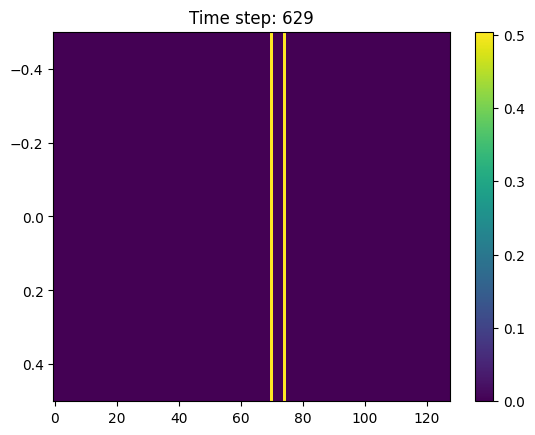

In [69]:
i = np.argmin([t.shape[0] for t in all_tensors])
tensor = all_tensors[i] 
animate_tensor(tensor, interval=100, save_path=f"/home/jamor/redes/midi_lstm/data/external/animation{i}.mp4")

Text(0.5, 1.0, 'Sum of velocity along time')

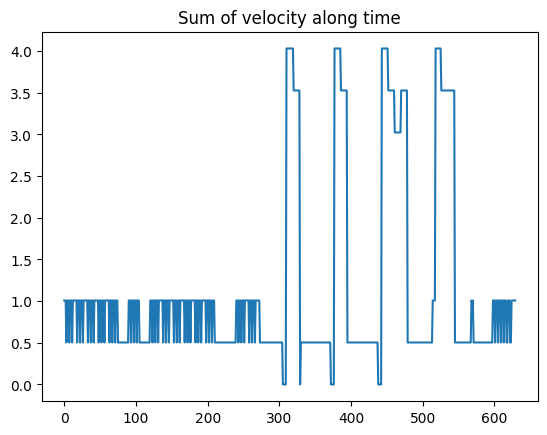

In [70]:
plt.plot(tensor.sum(axis=(1,2)))
plt.title("Sum of velocity along time")

In [63]:
[tensor.min(), tensor.mean() ,tensor.max()]

[tensor(0.), tensor(0.0032), tensor(0.8425)]

How is seen, is a very sparse tensor.

## Training

For the previous reason, i opted for weighted Binary Cross Entropy

In [11]:
#all_data = np.concatenate(all_tensors, axis=0) 
instruments = [0, 40, 42, 41, 48, 71, 60, 70, 73, 68, 43, 6]

""" pos_weights = []
for i in range(12):
    channel_data = all_data[:, i, :]
    ones  = channel_data.sum()
    zeros = channel_data.size - ones
    ratio = zeros / (ones + 1e-8)
    pos_weights.append(ratio)
    print(f"  instrument {i} program={instruments[i]:3d}  pos_weight={ratio:.1f}")

# BCEWithLogitsLoss accepts pos_weight broadcast over the last dimension
# we need shape (12, 128) — same weight for all pitches within an instrument
pw_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)  # (12,)
pw_tensor = pw_tensor.unsqueeze(1).expand(12, 128)   
criterion  = nn.BCEWithLogitsLoss(pos_weight=pw_tensor)  """
criterion = nn.MSELoss()

def compute_loss(labels, logits):
    """
    labels: (B, T, 12, 128)  (multi-hot, 0 or 1)
    logits: (B, T, 12, 128)  (raw outputs from model)
    """

    loss = criterion(logits, labels)
    return loss

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])

def train_step(x, y):
    model.train()

    optimizer.zero_grad()

    # Forward pass
    y_hat = model(x)  # (B, 30, 12, 128)

    # Loss (BCEWithLogitsLoss)
    loss = compute_loss(y.float(), y_hat)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # gradient clipping to prevent explosion
    optimizer.step()

    return loss

In [13]:
import mlflow

mlflow.set_experiment("lstm-midi-generation")
with mlflow.start_run():

    mlflow.log_params(params)

    history = []

    for iter in tqdm(range(params["num_training_iterations"])):

        x_batch, y_batch = get_batch( batch_size= params["batch_size"] )

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        loss = train_step(x_batch, y_batch)

        loss_value = loss.item()
        
        mlflow.log_metric("loss", loss_value, step=iter)

        history.append(loss_value)

        """ if iter % 100 == 0:
            print(f"Step {iter}, Loss: {loss_value:.4f}") """

        if iter % 100 == 0:
            checkpoint = {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "checkpoint_iter": iter,
            }
            torch.save(checkpoint, "checkpoint.pth")
            mlflow.log_artifact("checkpoint.pth")
    mlflow.pytorch.log_model(model, "model")

100%|██████████| 10/10 [00:10<00:00,  1.03s/it]
2026/03/26 09:28:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 09:28:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 09:28:07 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/26 09:28:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0

In [14]:
import plotly.express as px
fig = px.line(y=np.log(history))
fig.update_xaxes(title_text="Iteration")

## Generation

In [15]:
# diagnose actual values across your dataset before picking thresholds
densities      = []
unique_counts  = []
pitch_counts   = []

seq_length = 30
for song in all_tensors:
    for _ in range(5):    # sample 5 chunks per song
        T     = song.shape[0]
        start = np.random.randint(0, T - seq_length - 1)
        chunk = song[start : start + seq_length]

        densities.append(chunk.float().mean().item())
        flat = chunk.view(seq_length, -1)
        unique_counts.append(len(torch.unique(flat, dim=0)))
        pitch_counts.append((chunk.sum(dim=(0,1)) > 0).sum().item())

densities     = np.array(densities)
unique_counts = np.array(unique_counts)
pitch_counts  = np.array(pitch_counts)

print(f"density        min={densities.min():.4f}  median={np.median(densities):.4f}  max={densities.max():.4f}")
print(f"unique_frames  min={unique_counts.min()}  median={np.median(unique_counts):.0f}  max={unique_counts.max()}")
print(f"pitch_classes  min={pitch_counts.min()}  median={np.median(pitch_counts):.0f}  max={pitch_counts.max()}")

# show what fraction of chunks would pass at different thresholds
for d in [0.001, 0.005, 0.01, 0.02]:
    pct = (densities >= d).mean() * 100
    print(f"  density >= {d:.3f} → {pct:.1f}% of chunks pass")

density        min=0.0001  median=0.0012  max=0.0177
unique_frames  min=1  median=13  max=30
pitch_classes  min=2  median=14  max=40
  density >= 0.001 → 62.3% of chunks pass
  density >= 0.005 → 0.5% of chunks pass
  density >= 0.010 → 0.4% of chunks pass
  density >= 0.020 → 0.0% of chunks pass


In [16]:
# set thresholds at ~25th percentile so most chunks qualify
min_activity      = float(np.percentile(densities, 25))
min_unique_frames = int(np.percentile(unique_counts, 25))

print(f"using min_activity={min_activity:.4f}  min_unique_frames={min_unique_frames}")

using min_activity=0.0008  min_unique_frames=9


In [25]:
def pick_seed(all_tensors, seq_length=params["seq_length"], 
              min_activity=0.0008,    # at least 2% of cells active on average
              min_unique_frames=9, # at least 5 different frames (not all identical)
              n_candidates=30):     # pick the best out of N random candidates
    """
    Instead of taking the first chunk that passes a low bar,
    sample N candidates and pick the most dynamic one.
    """
    best_chunk = None
    best_score = -1

    for _ in range(n_candidates):
        song  = all_tensors[np.random.randint(len(all_tensors))]
        T     = song.shape[0]
        start = np.random.randint(0, T - seq_length - 1)
        chunk = song[start : start + seq_length]   # (30, 12, 128)

        # metric 1: average note density across the chunk
        density = chunk.float().mean().item()

        # metric 2: how many unique frames (variety, not repetition)
        flat         = chunk.view(seq_length, -1)
        unique_frames = len(torch.unique(flat, dim=0))

        # metric 3: how many distinct pitch classes are active
        pitch_usage  = chunk.sum(dim=(0, 1))        # (128,) — usage per pitch
        active_pitches = (pitch_usage > 0).sum().item()

        # skip chunks that are too sparse or too repetitive
        if density < min_activity or unique_frames < min_unique_frames:
            continue

        # score: reward density and variety equally
        score = density * (unique_frames / seq_length) * (active_pitches / 128)

        if score > best_score:
            best_score = score
            best_chunk = chunk

    if best_chunk is None:
        raise ValueError("no suitable seed found — lower min_activity or min_unique_frames")

    return best_chunk

In [26]:
# Simulate a batch from your converted MIDIs — durations vary, pad or chunk as needed
x = torch.rand(8, 30, 12, 128).to(device)   # (B=8, T=30, 12, 128)
out = model(x)
print("Input :", x.shape)    # (8, 30, 12, 128)
print("Output:", out.shape)  # (8, 30, 12, 128)

def generate(model, 
            all_tensors, 
            generation_length=500, 
            temperature=1.0,
            max_polyphony=8,
            reseed_every=40,
            reseed_blend=0.5,
            silence_threshold=0.3,
            stuck_window=2,          # frames to check for repetition
             stuck_threshold=0.95,    # similarity above this = stuck
             stuck_noise=0.05):
    model.eval()
    state = model.init_hidden(1, device)
    idx = np.random.randint(len(all_tensors))
    song = all_tensors[idx]  # shape (T_song, 12, 128)
    chunk = pick_seed(all_tensors)
    x_t = torch.tensor(chunk).unsqueeze(0).float().to(device)
    generated_frames = [x_t]
    recent_frames    = []   # sliding window to detect repetition
    current_temp     = temperature
    with torch.no_grad(): 
        for t in range(generation_length):
            out, state = model(x_t, state, return_state=True)  # (1, 30, 12, 128)
            logits = out[:, -1] / current_temp 
            probs  = torch.sigmoid(logits)
            flat = probs.view(-1)
            next_flat = torch.zeros_like(flat)
            """ if flat.max() >= silence_threshold:
                topk_vals, topk_idx = torch.topk(flat, max_polyphony)
                # only activate notes that cleared the threshold
                active = topk_vals >= silence_threshold
                next_flat[topk_idx[active]] = 1.0 """

            next_frame = next_flat.view(1, 12, 128)    # all zeros = rest frame
            recent_frames.append(next_frame.clone())
            """ if len(recent_frames) > stuck_window:
                recent_frames.pop(0)
            if len(recent_frames) == stuck_window:
                # compute pairwise similarity across recent frames
                stacked   = torch.stack(recent_frames).squeeze(1)   # (W, 12, 128)
                ref       = stacked[0]
                diffs     = (stacked - ref).abs().sum(dim=(1, 2))    # (W,)
                is_stuck  = (diffs < 2).float().mean().item()        # fraction identical

                if is_stuck >= stuck_threshold:
                    # ── escape 1: raise temperature temporarily ───────────────
                    current_temp = min(temperature * 2.5, 2.0)

                    # ── escape 2: inject noise into hidden state ──────────────
                    h, c  = state
                    h     = h + torch.randn_like(h) * stuck_noise
                    c     = c + torch.randn_like(c) * stuck_noise
                    state = (h, c)

                    recent_frames.clear()   # reset window after escape
                else:
                    # gradually return to normal temperature
                    current_temp = max(current_temp * 0.98, temperature) """

            generated_frames.append(next_frame.unsqueeze(1))

            """ if (t + 1) % reseed_every == 0:
                rs_song    = all_tensors[np.random.randint(len(all_tensors))]
                rs_idx     = np.random.randint(0, rs_song.shape[0])
                real_frame = torch.tensor(
                    rs_song[rs_idx], dtype=torch.float32
                ).unsqueeze(0).unsqueeze(1).to(device)
                blended = reseed_blend * real_frame + (1 - reseed_blend) * next_frame.unsqueeze(1)
                x_t = torch.cat([x_t[:, 1:], blended], dim=1)
            else:
                x_t = torch.cat([x_t[:, 1:], next_frame.unsqueeze(1)], dim=1) """
            x_t = torch.cat([x_t[:, 1:], next_frame.unsqueeze(1)], dim=1)
    generated = torch.cat(generated_frames, dim=1)
    return generated.squeeze(0).detach().cpu().numpy()

Input : torch.Size([8, 30, 12, 128])
Output: torch.Size([8, 30, 12, 128])


In [27]:

import pathlib
import numpy as np

out_dir = pathlib.Path("/home/jamor/redes/midi_lstm/data/processed/generated_tensors")
out_dir.mkdir(parents=True, exist_ok=True)
safe_name = pathlib.Path("generated"+str(time.time())).stem

gen_tensor =  generate(model, all_tensors)
np.save(out_dir / f"{safe_name}.npy", gen_tensor)
gen_tensor.shape

/tmp/ipykernel_379471/1853851232.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_t = torch.tensor(chunk).unsqueeze(0).float().to(device)


(620, 12, 128)

# Convert to mp3

In [28]:
import pathlib
import pretty_midi
import numpy as np
from pydub import AudioSegment
from IPython.display import Audio, display

def tensor_to_midi(tensor, instruments = [0, 40, 42, 41, 48, 71, 60, 70, 73, 68, 43, 6], hz=10):
    """
    tensor: (T, num_instruments, 128) uint8 or float
    instruments: list of MIDI program numbers
    hz: time resolution used during encoding
    """

    T, num_inst, num_pitches = tensor.shape
    assert num_pitches == 128

    pm = pretty_midi.PrettyMIDI()

    for inst_index, program in enumerate(instruments):
        instrument = pretty_midi.Instrument(program=program)

        # (T, 128)
        roll = tensor[:, inst_index, :]

        # If normalized, convert back
        if roll.dtype != np.uint8:
            roll = (roll * 127).astype(np.uint8)

        for pitch in range(128):
            velocities = np.maximum(1, (roll[:, pitch] * 127).astype(np.uint8))

            active = velocities > 0

            note_on = None
            velocity = 0

            for t in range(T):
                if active[t]:
                    if note_on is None:
                        # NOTE ON
                        note_on = t
                        velocity = int(velocities[t])
                else:
                    if note_on is not None:
                        # NOTE OFF
                        start = note_on / hz
                        end = t / hz

                        note = pretty_midi.Note(
                            velocity=velocity,
                            pitch=pitch,
                            start=start,
                            end=end
                        )
                        instrument.notes.append(note)

                        note_on = None

            # Handle note that lasts until end
            if note_on is not None:
                start = note_on / hz
                end = T / hz

                note = pretty_midi.Note(
                    velocity=int(velocity),
                    pitch=pitch,
                    start=start,
                    end=end
                )
                instrument.notes.append(note)

        pm.instruments.append(instrument)

    return pm

In [29]:
sample_tensor = np.load(out_dir / f"{safe_name}.npy").squeeze()
sample_tensor.shape

(620, 12, 128)

In [30]:
sample_tensor.sum(axis=(0,2)) 

array([202.77158,   0.     , 195.11806,   0.     ,   0.     ,   0.     ,
         0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ],
      dtype=float32)

In [31]:
sample_tensor

instruments = [0, 40, 42, 41, 48, 71, 60, 70, 73, 68, 43, 6]
print("activity per instrument channel:")
for i, program in enumerate(instruments):
    active_frames = (sample_tensor[:, i, :] > 0).any(axis=1).sum()
    total_notes   = (sample_tensor[:, i, :] > 0).sum()
    print(f"  idx={i} program={program:3d}  active_frames={active_frames:4d}  notes={total_notes}")

activity per instrument channel:
  idx=0 program=  0  active_frames= 119  notes=278
  idx=1 program= 40  active_frames=   0  notes=0
  idx=2 program= 42  active_frames= 120  notes=225
  idx=3 program= 41  active_frames=   0  notes=0
  idx=4 program= 48  active_frames=   0  notes=0
  idx=5 program= 71  active_frames=   0  notes=0
  idx=6 program= 60  active_frames=   0  notes=0
  idx=7 program= 70  active_frames=   0  notes=0
  idx=8 program= 73  active_frames=   0  notes=0
  idx=9 program= 68  active_frames=   0  notes=0
  idx=10 program= 43  active_frames=   0  notes=0
  idx=11 program=  6  active_frames=   0  notes=0


In [32]:
pm = tensor_to_midi(sample_tensor)
sr = 22050
audio = None
try:
    audio = pm.fluidsynth(fs=sr)
    print("Used fluidsynth")
except Exception as e:
    print("fluidsynth failed:", e)
if audio is None:
    audio = pm.synthesize(fs=sr)
    print("Used synthesize fallback")

audio_int16 = np.int16(np.clip(audio * 32767, -32768, 32767))
wav_segment = AudioSegment(
    audio_int16.tobytes(),
    frame_rate=sr,
    sample_width=2,
    channels=1
)

out_dir = pathlib.Path("/home/jamor/redes/midi_lstm/data/interim/generated_audio")
out_dir.mkdir(parents=True, exist_ok=True)
wav_segment.export(out_dir / f"{safe_name}.mp3", format="mp3", bitrate="192k")
print("Exported MP3 to:", out_dir / f"{safe_name}.mp3")

display(Audio(str(out_dir / f"{safe_name}.mp3")))

fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=42)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=43)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=44)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=45)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=46)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=47)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=48)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=49)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=50)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=51)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=52)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=53)
fluidsynth: warning: Failed to allocate a synthesis process. (chan=0,key=54)

Used fluidsynth
Exported MP3 to: /home/jamor/redes/midi_lstm/data/interim/generated_audio/generated1774542601.mp3


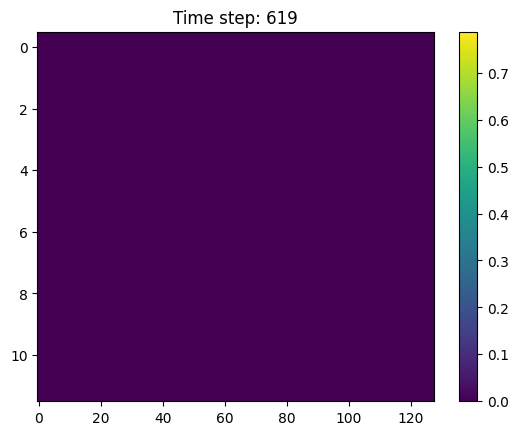

In [33]:
#animate_tensor(sample_tensor, interval=50, save_path=f"/home/jamor/redes/midi_lstm/data/external/generated{time.time()}.gif")